## Textbook code

In [1]:
# coding: utf-8
import sys
import os
sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

In [8]:


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784,
                            hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd',
                      optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# 하이퍼파라미터 무작위 탐색======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 탐색한 하이퍼파라미터의 범위 지정===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list


val acc:0.08 | lr:3.2693014659428357e-06, weight decay:1.0077498181111212e-06
val acc:0.76 | lr:0.00916023786380924, weight decay:1.8183687092468003e-06
val acc:0.76 | lr:0.008982412121674162, weight decay:1.3344519815644275e-06
val acc:0.21 | lr:0.0008251364474353077, weight decay:2.7474210451771388e-08
val acc:0.05 | lr:1.0370938914389163e-06, weight decay:2.917138286883681e-06
val acc:0.08 | lr:0.00010047952585006385, weight decay:4.838864431884854e-06
val acc:0.09 | lr:2.099506958935311e-06, weight decay:5.894360025890663e-07
val acc:0.64 | lr:0.005085978040194249, weight decay:9.72653283354327e-08
val acc:0.18 | lr:0.0011266064407347617, weight decay:9.58272969474021e-05
val acc:0.13 | lr:4.0888237464657666e-06, weight decay:8.032343117675748e-06
val acc:0.08 | lr:1.981538918289644e-05, weight decay:2.4591803598000016e-06
val acc:0.47 | lr:0.0022522207597708774, weight decay:1.6575862540178965e-08
val acc:0.48 | lr:0.0034576234020858646, weight decay:1.1968788451280328e-07
val acc

=========== Hyper-Parameter Optimization Result ===========
Best-1(val acc:0.83) | lr:0.009273033667926554, weight decay:2.2005949476181338e-07
Best-2(val acc:0.78) | lr:0.007461057427319899, weight decay:6.318450010498612e-06
Best-3(val acc:0.78) | lr:0.0077554705094775855, weight decay:3.4307140819181065e-07
Best-4(val acc:0.76) | lr:0.00916023786380924, weight decay:1.8183687092468003e-06
Best-5(val acc:0.76) | lr:0.008982412121674162, weight decay:1.3344519815644275e-06
Best-6(val acc:0.75) | lr:0.008299807779507245, weight decay:3.8429284560402534e-07
Best-7(val acc:0.75) | lr:0.00825866299607812, weight decay:1.2553089870598712e-06
Best-8(val acc:0.73) | lr:0.005895482545644892, weight decay:3.456396777368973e-05
Best-9(val acc:0.71) | lr:0.0061663152946123305, weight decay:3.3105217759700986e-06
Best-10(val acc:0.7) | lr:0.0048568052474994685, weight decay:2.8639735106158648e-08
Best-11(val acc:0.64) | lr:0.005085978040194249, weight decay:9.72653283354327e-08
Best-12(val acc:0.

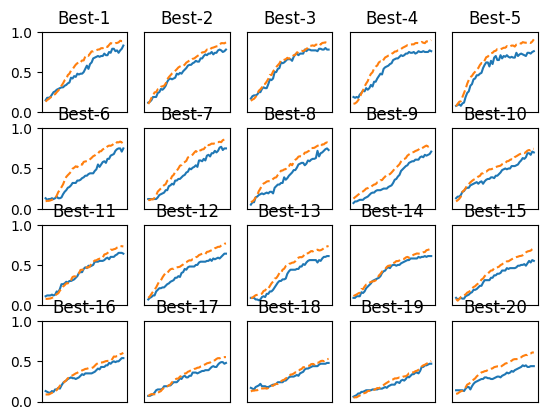

In [9]:
# 그래프 그리기========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x: x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5:
        plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()



## My code

In [14]:
import sys, os, math, random
sys.path.append('./official_github/')
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
sys.path.append('./official_github/')

from dataset.mnist import load_mnist
from my_models import MultiLayerNet, SGD

In [15]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val, t_val = x_train[:validation_num], t_train[:validation_num]
x_train, t_train = x_train[validation_num:], t_train[validation_num:]



In [16]:
def get_new_range(valid_acc_dict, top=10):
    sorted_list = sorted(valid_acc_dict.items(), key=lambda x: x[1][-1], reverse=True)
    # sorted_list = sorted(sorted_list, key=lambda x: x[0])
    sorted_list = sorted(sorted_list[:top+1], key=lambda x: x[0])
    min_value, max_value = sorted_list[0][0], sorted_list[-1][0]
    
    return min_value, max_value

===== 1th trial =====
lr: 0.1655363276620465
valid acc: 0.17
valid acc: 0.68
valid acc: 0.88
valid acc: 0.88
valid acc: 0.88
valid acc: 0.88
lr: 1.2712114250346502
valid acc: 0.1
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 1.2935107530305117
valid acc: 0.1
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 0.6514781472278997
valid acc: 0.14
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 0.42369109900384894
valid acc: 0.14
valid acc: 0.33
valid acc: 0.48
valid acc: 0.53
valid acc: 0.76
valid acc: 0.69
lr: 0.9583884311243833
valid acc: 0.14
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 1.3333765960526456
valid acc: 0.14
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 1.8348995470528888
valid acc: 0.07
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
valid acc: 0.08
lr: 1.3390558069747327
vali

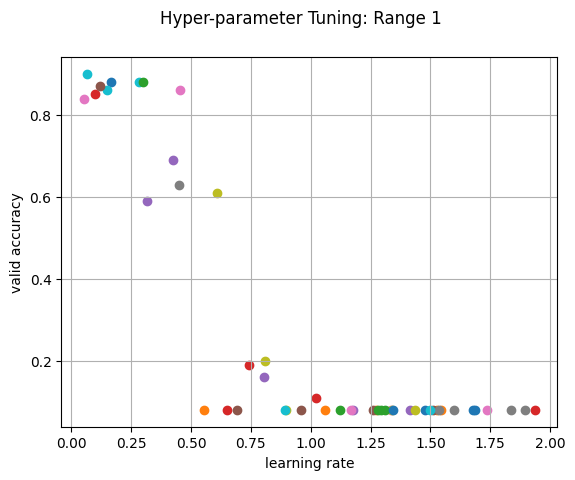

1 trial with 50:  0.06485946236715967, 0.28279628037598803
===== 2th trial =====
lr: 0.24925352433496784
valid acc: 0.19
valid acc: 0.71
valid acc: 0.87
valid acc: 0.89
valid acc: 0.89
valid acc: 0.89
lr: 0.07097020367616373
valid acc: 0.12
valid acc: 0.63
valid acc: 0.87
valid acc: 0.86
valid acc: 0.85
valid acc: 0.84
lr: 0.230556020345854
valid acc: 0.18
valid acc: 0.74
valid acc: 0.87
valid acc: 0.88
valid acc: 0.89
valid acc: 0.89
lr: 0.2500949277457591
valid acc: 0.07
valid acc: 0.61
valid acc: 0.86
valid acc: 0.86
valid acc: 0.85
valid acc: 0.84
lr: 0.08271625458492088
valid acc: 0.1
valid acc: 0.83
valid acc: 0.87
valid acc: 0.87
valid acc: 0.86
valid acc: 0.87
lr: 0.2705644472584535
valid acc: 0.07
valid acc: 0.36
valid acc: 0.54
valid acc: 0.79
valid acc: 0.08
valid acc: 0.08
lr: 0.16263890006749215
valid acc: 0.1
valid acc: 0.88
valid acc: 0.88
valid acc: 0.9
valid acc: 0.9
valid acc: 0.9
lr: 0.11895168837326991
valid acc: 0.17
valid acc: 0.83
valid acc: 0.89
valid acc: 0.89


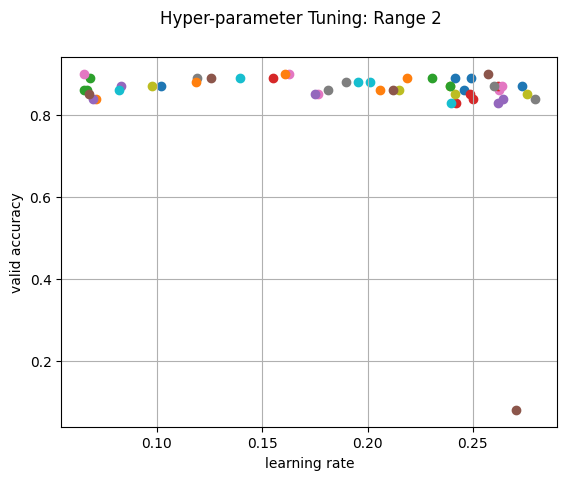

2 trial with 50:  0.06530582964856227, 0.2571819570185497
===== 3th trial =====
lr: 0.12687161362772695
valid acc: 0.12
valid acc: 0.83
valid acc: 0.86
valid acc: 0.88
valid acc: 0.87
valid acc: 0.87
lr: 0.09613694067071656
valid acc: 0.12
valid acc: 0.74
valid acc: 0.89
valid acc: 0.88
valid acc: 0.88
valid acc: 0.89
lr: 0.19850184935291657
valid acc: 0.14
valid acc: 0.82
valid acc: 0.85
valid acc: 0.86
valid acc: 0.86
valid acc: 0.86
lr: 0.12709699317884876
valid acc: 0.2
valid acc: 0.87
valid acc: 0.86
valid acc: 0.86
valid acc: 0.85
valid acc: 0.86
lr: 0.12797978015693023
valid acc: 0.21
valid acc: 0.81
valid acc: 0.82
valid acc: 0.83
valid acc: 0.84
valid acc: 0.84
lr: 0.11208776905549679
valid acc: 0.11
valid acc: 0.76
valid acc: 0.86
valid acc: 0.86
valid acc: 0.86
valid acc: 0.86
lr: 0.15441879156943056
valid acc: 0.15
valid acc: 0.87
valid acc: 0.88
valid acc: 0.9
valid acc: 0.89
valid acc: 0.89
lr: 0.16244079463340078
valid acc: 0.29
valid acc: 0.78
valid acc: 0.88
valid acc:

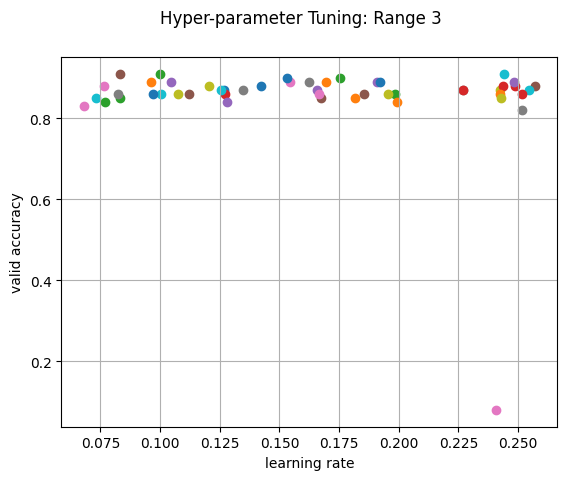

3 trial with 50:  0.08333233113475032, 0.244038360731907
===== 4th trial =====
lr: 0.12015550633500427
valid acc: 0.15
valid acc: 0.65
valid acc: 0.85
valid acc: 0.84
valid acc: 0.85
valid acc: 0.85
lr: 0.20961399966981503
valid acc: 0.07
valid acc: 0.71
valid acc: 0.86
valid acc: 0.86
valid acc: 0.85
valid acc: 0.84
lr: 0.20999852566499783
valid acc: 0.18
valid acc: 0.66
valid acc: 0.58
valid acc: 0.86
valid acc: 0.79
valid acc: 0.81
lr: 0.21641701415039155
valid acc: 0.26
valid acc: 0.5
valid acc: 0.64
valid acc: 0.7
valid acc: 0.84
valid acc: 0.88
lr: 0.22392604139217126
valid acc: 0.14
valid acc: 0.79
valid acc: 0.87
valid acc: 0.88
valid acc: 0.89
valid acc: 0.89
lr: 0.11979109315773272
valid acc: 0.13
valid acc: 0.83
valid acc: 0.83
valid acc: 0.87
valid acc: 0.88
valid acc: 0.87
lr: 0.1726741217509432
valid acc: 0.2
valid acc: 0.58
valid acc: 0.87
valid acc: 0.87
valid acc: 0.86
valid acc: 0.86
lr: 0.1487469106435943
valid acc: 0.11
valid acc: 0.64
valid acc: 0.86
valid acc: 0.8

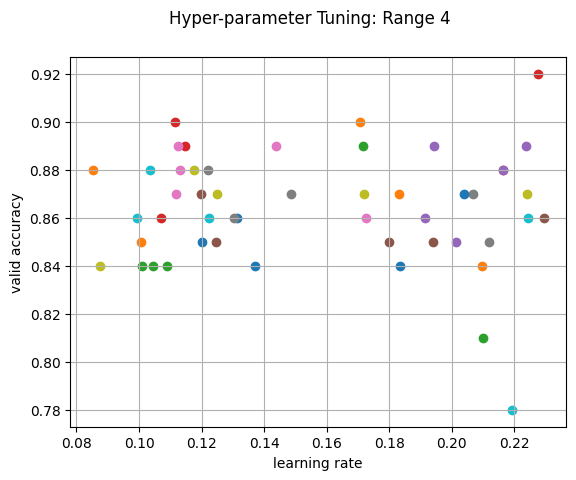

4 trial with 50:  0.11156095990042861, 0.22768785492548232


In [17]:
total_trial = 4
outputs_dict = {}
min_value, max_value = 0, 2
trial = 50

for trial_idx in range(1, total_trial+1):
    print(f'===== {trial_idx}th trial =====')
    outputs_dict[trial_idx] = defaultdict(list)
    
    for _ in range(trial):
        lr = random.uniform(min_value, max_value)
        print(f'lr: {lr}')
        network = MultiLayerNet(784, [100, 100, 100, 100, 100, 100], 10,)
        optimizer = SGD(lr=lr)
        for i in range(300):
            batch_mask = np.random.choice(x_train.shape[0], 100)
            x_batch = x_train[batch_mask]
            t_batch = t_train[batch_mask]

            grads = network.gradient(x_batch, t_batch)
            optimizer.update(network.params, grads)

            if i % 50 == 0:
                acc = network.accuracy(x_val, t_val)
                print(f'valid acc: {acc}')
                outputs_dict[trial_idx][lr].append(acc)
    
    for key, value in outputs_dict[trial_idx].items():
        # print(key, value[-1])
        plt.scatter(key, value[-1], label=key)

    # plt.legend()
    plt.grid()
    # plt.ylim(0.6, 1.01)
    # plt.xlim(-1, 1)
    plt.xlabel('learning rate')
    plt.ylabel('valid accuracy')
    plt.suptitle(f'Hyper-parameter Tuning: Range {trial_idx}')
    plt.show()

    min_value, max_value = get_new_range(outputs_dict[trial_idx], top=2)
    print(f'{trial_idx} trial with {trial}:  {min_value}, {max_value}')

    